# Diseño Analítico y Simulación del Amplificador Compuesto VFA-VFA

Este cuaderno automatiza los cálculos de diseño para un amplificador compuesto basado en dos operacionales LM324, buscando satisfacer una ganancia global de $20\text{ dB}$ con una condición de máxima planicidad de módulo ($Q_p = 0,707$).

**Objetivo de esta celda:** Importar las librerías necesarias para el manejo de arreglos matemáticos, creación de funciones de transferencia y graficación de los diagramas de Bode.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from matplotlib.ticker import MultipleLocator

# Configuración estética profesional para los gráficos
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

## 1. Parámetros del Dispositivo y Cálculos de Diseño

**Objetivo de esta celda:** Definir las características de lazo abierto del LM324 y calcular la ganancia local requerida en el segundo amplificador ($A_{02}$) para garantizar la estabilidad del lazo global mediante la técnica de "Separación de Polos".

**Ecuaciones utilizadas:**
1. Conversión de Ganancia Global a valor lineal:
   $$A_{vf} = 10^{\frac{A_{vf(dB)}}{20}}$$
2. Factor de realimentación global (K):
   $$K = \frac{1}{A_{vf}}$$
3. Ganancia local del segundo amplificador para obtener $Q_p = 0,707$ (Separación óptima de polos):
   $$Avf_2 = \sqrt{\frac{A_{vf}}{2}}$$

In [28]:
# 1. Parámetros del LM324 (VFA)
Ad0_dB = 100
Ad0 = 10**(Ad0_dB / 20)  # Ganancia lineal: 100,000 V/V
f1 = 10.0                # Primer polo original: 10 Hz
f2 = 5.06e6              # Segundo polo original: 5.06 MHz
w1 = 2 * np.pi * f1
w2 = 2 * np.pi * f2

# 2. Requerimientos de la Cátedra
Avf_global_dB = 20
Avf_global = 10**(Avf_global_dB / 20)  # 10 V/V

# Factor de realimentación global (beta)
K_global = 1 / Avf_global

# 3. Diseño de la etapa A02 (Compensación por separación de polos)
Avf2 = np.sqrt(Avf_global / 2)

print(f"--- RESULTADOS DE DISEÑO ---")
print(f"Ganancia global deseada (A_vf): {Avf_global:.2f} V/V")
print(f"Factor de realimentación global (beta): {K_global:.3f}")
print(f"Ganancia local requerida en A02 (Avf2): {Avf2:.3f} V/V")
print(f"Polos a Lazo Cerrado (Hz): {sys_global.poles / (2 * np.pi)}")

--- RESULTADOS DE DISEÑO ---
Ganancia global deseada (A_vf): 10.00 V/V
Factor de realimentación global (beta): 0.100
Ganancia local requerida en A02 (Avf2): 2.236 V/V
Polos a Lazo Cerrado (Hz): [-5081487.15285517     +0.j          -212868.2213224 +232956.48073188j
  -212868.2213224 -232956.48073188j]


## 2. Modelado de Funciones de Transferencia

**Objetivo de esta celda:** Construir los modelos matemáticos en el dominio de Laplace para cada bloque del circuito y obtener la función de transferencia a lazo cerrado global.

**Ecuaciones utilizadas:**
1. Función de $A_{01}$ a lazo abierto (2 polos):
   $$A_1(s) = \frac{Ad_0}{(1 + \frac{s}{\omega_1})(1 + \frac{s}{\omega_2})}$$
2. Producto Ganancia-Ancho de Banda ($\omega_T$):
   $$\omega_T = Ad_0 \cdot \omega_1$$
3. Desplazamiento del polo de $A_{02}$ al cerrar su lazo local:
   $$\omega_{px} = \frac{\omega_T}{Avf_2}$$
4. Función de $A_{02}$ a lazo cerrado (1 polo dominante):
   $$A_{2f}(s) = \frac{Avf_2}{1 + \frac{s}{\omega_{px}}}$$
5. Función de Transferencia Global a Lazo Cerrado (Ecuación de Black):
   $$A_{vf\_global}(s) = \frac{A_1(s) \cdot A_{2f}(s)}{1 + K \cdot A_1(s) \cdot A_{2f}(s)}$$

In [29]:
# Producto Ganancia-Ancho de Banda en rad/s
wT = Ad0 * w1  

# Nuevo polo desplazado de A02
w_px = wT / Avf2 
f_px = w_px / (2 * np.pi)

# Modelo de A01 (Lazo abierto con 2 polos)
num_A1 = [Ad0 * w1 * w2]
den_A1 = [1, (w1 + w2), w1 * w2]
sys_A1 = signal.TransferFunction(num_A1, den_A1)

# Modelo de A02 (A lazo cerrado con 1 polo dominante desplazado)
num_A2 = [Avf2 * w_px]
den_A2 = [1, w_px]
sys_A2 = signal.TransferFunction(num_A2, den_A2)

# Trayectoria Directa (A01 en cascada con A02)
num_dir = np.convolve(num_A1, num_A2)
den_dir = np.convolve(den_A1, den_A2)

# Función de Transferencia Global a Lazo Cerrado
num_global = num_dir
den_global = np.polyadd(den_dir, K_global * num_dir)
sys_global = signal.TransferFunction(num_global, den_global)

print(f"Frecuencia del polo desplazado en A02 (f_px): {f_px / 1000:.2f} kHz")

Frecuencia del polo desplazado en A02 (f_px): 447.21 kHz


## 3. Diagramas de Bode y Verificación de Estabilidad

**Objetivo de esta celda:** Graficar la respuesta en frecuencia (Módulo y Fase) del sistema global. Se insertan marcadores verticales en las frecuencias exactas de los polos ($f_1$, $f_{px}$, $f_2$) para evidenciar cómo estos provocan los cambios de pendiente y acumulación de desfase, validando el diseño analítico.

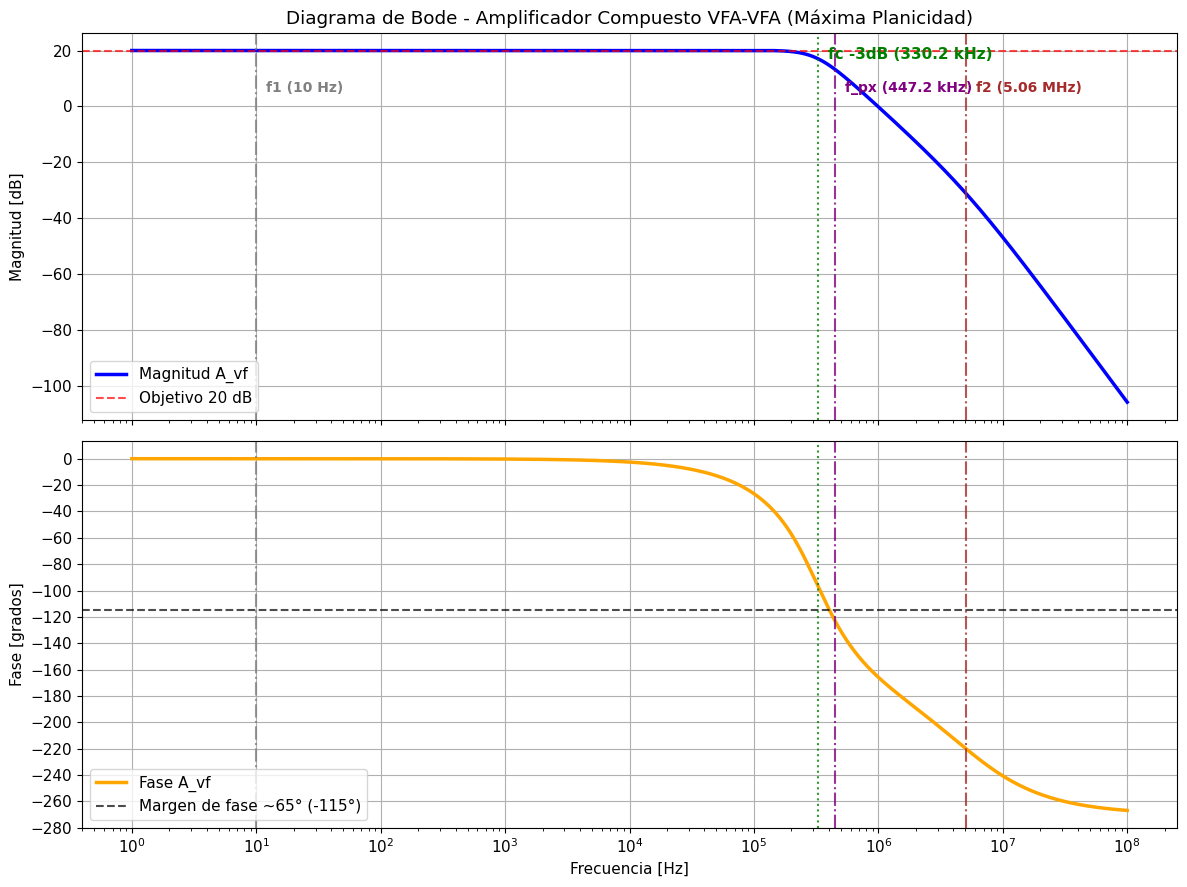

--- VERIFICACIÓN FINAL ---
Frecuencia de corte (-3dB) medida en gráfico: 330.19 kHz


In [30]:
# Rango de frecuencias para el gráfico (de 1 Hz a 100 MHz)
f_bode = np.logspace(0, 8, 2000)
w_bode = 2 * np.pi * f_bode

# Calcular respuesta en frecuencia
w, mag, phase = signal.bode(sys_global, w_bode)
f_hz = w / (2 * np.pi)

# Encontrar ancho de banda a -3dB
mag_max = np.max(mag)
idx_3db = np.where(mag <= mag_max - 3)[0][0]
f_3db = f_hz[idx_3db]

# Creación de la figura
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# ---------------- GRÁFICO DE AMPLITUD ----------------
ax1.semilogx(f_hz, mag, color='blue', linewidth=2.5, label='Magnitud A_vf')
ax1.set_title('Diagrama de Bode - Amplificador Compuesto VFA-VFA (Máxima Planicidad)')
ax1.set_ylabel('Magnitud [dB]')
ax1.axhline(20, color='red', linestyle='--', alpha=0.7, label='Objetivo 20 dB')

# Marcadores para los polos y corte en Amplitud
poles = [(f1, 'f1 (10 Hz)', 'gray'), 
         (f_px, f'f_px ({f_px/1000:.1f} kHz)', 'purple'), 
         (f2, f'f2 ({f2/1e6:.2f} MHz)', 'brown')]

for p_freq, p_label, p_color in poles:
    ax1.axvline(p_freq, color=p_color, linestyle='-.', alpha=0.8)
    # Etiqueta posicionada dinámicamente
    ax1.text(p_freq * 1.2, 5, p_label, color=p_color, fontsize=10, weight='bold')

ax1.axvline(f_3db, color='green', linestyle=':', alpha=0.8)
ax1.text(f_3db * 1.2, 17, f'fc -3dB ({f_3db/1000:.1f} kHz)', color='green', weight='bold')
ax1.legend(loc='lower left')

# ---------------- GRÁFICO DE FASE ----------------
ax2.semilogx(f_hz, phase, color='orange', linewidth=2.5, label='Fase A_vf')
ax2.set_ylabel('Fase [grados]')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.axhline(-115, color='black', linestyle='--', alpha=0.7, label='Margen de fase ~65° (-115°)')

ax2.yaxis.set_major_locator(MultipleLocator(20))

# Repetir marcadores verticales en la fase
for p_freq, p_label, p_color in poles:
    ax2.axvline(p_freq, color=p_color, linestyle='-.', alpha=0.8)

ax2.axvline(f_3db, color='green', linestyle=':', alpha=0.8)
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

print(f"--- VERIFICACIÓN FINAL ---")
print(f"Frecuencia de corte (-3dB) medida en gráfico: {f_3db / 1000:.2f} kHz")

## 4. Cálculo de Componentes Pasivos (Resistencias)

**Objetivo de esta celda:** Calcular los valores óhmicos exactos para las redes de realimentación global y local. 

Se adopta un criterio de diseño fijando valores base para las resistencias conectadas a tierra ($R_i$ y $R_1$) en rangos de $1k\Omega$ a $10k\Omega$ para minimizar el ruido térmico sin cargar excesivamente a los operacionales.

**Ecuaciones utilizadas:**
1. Malla Global: $A_{vf} = 1 + \frac{R_f}{R_i} \Rightarrow R_f = R_i \cdot (A_{vf} - 1)$
2. Malla Local (A02): $Avf_2 = 1 + \frac{R_2}{R_1} \Rightarrow R_2 = R_1 \cdot (Avf_2 - 1)$

In [25]:
# Fijamos valores base estándar para las resistencias a tierra (en Ohms)
Ri = 1000.0   # 1 kOhm para el lazo global
R1 = 10000.0  # 10 kOhm para el lazo local de A02

# Cálculo de las resistencias de realimentación
Rf = Ri * (Avf_global - 1)
R2 = R1 * (Avf2 - 1)

print("--- CÁLCULO DE RESISTENCIAS TEÓRICAS ---")
print(f"Lazo Global (Avf = {Avf_global:.2f} V/V):")
print(f"Ri = {Ri/1000:.1f} kΩ")
print(f"Rf = {Rf/1000:.2f} kΩ")

print(f"\nLazo Local A02 (Avf2 = {Avf2:.3f} V/V):")
print(f"R1 = {R1/1000:.1f} kΩ")
print(f"R2 = {R2/1000:.3f} kΩ")

# --- Sugerencia de valores comerciales E96 (1% de tolerancia) ---
print("\n--- VALORES COMERCIALES SUGERIDOS (Serie E96 - 1%) ---")
print("Para Rf (Teórico 9.00 kΩ) -> Usar 9.09 kΩ o un arreglo serie (e.g. 4.7k + 4.3k)")
print("Para R2 (Teórico 12.36 kΩ) -> Usar 12.4 kΩ")

--- CÁLCULO DE RESISTENCIAS TEÓRICAS ---
Lazo Global (Avf = 10.00 V/V):
Ri = 1.0 kΩ
Rf = 9.00 kΩ

Lazo Local A02 (Avf2 = 2.236 V/V):
R1 = 10.0 kΩ
R2 = 12.361 kΩ

--- VALORES COMERCIALES SUGERIDOS (Serie E96 - 1%) ---
Para Rf (Teórico 9.00 kΩ) -> Usar 9.09 kΩ o un arreglo serie (e.g. 4.7k + 4.3k)
Para R2 (Teórico 12.36 kΩ) -> Usar 12.4 kΩ
